# Benchmark Training & Evaluation (Memory-Optimized)

Train 3 mô hình benchmark trên dataset forecasting, đánh giá và so sánh.

**Các thay đổi v2:**
- Bỏ Random Forest (quá chậm trên dataset lớn)
- Loại bỏ weather columns bị rò rỉ vào h24_energy (bug trong pipeline)
- Loại bỏ các cột không hữu ích (lat, lng, timezone, site_id)
- Tối ưu hyperparameters cho XGBoost/LightGBM
- Thêm `consumption` vào EXCLUDE nếu muốn fair evaluation
- XGBoost/LightGBM dùng `device='cuda'` nếu T4 có sẵn
- Thêm RAM monitor để theo dõi


## 1. Install & Import

In [1]:
!pip install -q polars xgboost lightgbm scikit-learn joblib matplotlib huggingface_hub

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [1]:
import os, gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import joblib
import psutil

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb

def ram_usage():
    """In mức RAM hiện tại đang dùng."""
    used = psutil.Process().memory_info().rss / 1024**3
    total = psutil.virtual_memory().total / 1024**3
    print(f'  [RAM] {used:.2f} GB / {total:.2f} GB ({used/total*100:.1f}%)')

print('All imports OK')
ram_usage()

All imports OK
  [RAM] 0.23 GB / 15.79 GB (1.5%)


## 2. Config

In [3]:
# --- Dataset config ---
HF_REPO_ID = "PandaLT/Forecasting-dataset"
DATASET_SUBFOLDER = "h24_energy"

# --- Output dirs ---
OUTPUT_BASE = "D:/dmp-project/result/output_energy_24h"
MODELS_DIR = os.path.join(OUTPUT_BASE, "models")
REPORT_DIR = os.path.join(OUTPUT_BASE, "report")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Kiểm tra GPU ---
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
except Exception:
    HAS_GPU = False

TREE_DEVICE = 'cuda' if HAS_GPU else 'cpu'
print(f'Output: {OUTPUT_BASE}')
print(f'Dataset: {HF_REPO_ID} / {DATASET_SUBFOLDER}')
print(f'GPU available: {HAS_GPU} → tree models will use: {TREE_DEVICE}')

Output: D:/dmp-project/result/output_energy_24h
Dataset: PandaLT/Forecasting-dataset / h24_energy
GPU available: True → tree models will use: cuda


## 3. Load Dataset from Hugging Face

In [6]:
from huggingface_hub import snapshot_download

local_data = snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
)
DATA_DIR = os.path.join(local_data, "dataset", DATASET_SUBFOLDER)
print(f'Downloaded to: {local_data}')
print(f'Data folder: {DATA_DIR}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--PandaLT--Forecasting-dataset/snapshots/383932eedb32ce04375dbaaa03c93b2e505db25a
Data folder: /root/.cache/huggingface/hub/datasets--PandaLT--Forecasting-dataset/snapshots/383932eedb32ce04375dbaaa03c93b2e505db25a/dataset/h24_energy


In [8]:
train = pl.read_parquet("D:/dmp-project/data/processed/forecasting/dataset/h24_energy/train.parquet")
val   = pl.read_parquet("D:/dmp-project/data/processed/forecasting/dataset/h24_energy/validation.parquet")
test  = pl.read_parquet("D:/dmp-project/data/processed/forecasting/dataset/h24_energy/test.parquet")

print(f'Train:      {train.shape[0]:>10,} rows | {train["timestamp"].min()} → {train["timestamp"].max()}')
print(f'Validation: {val.shape[0]:>10,} rows | {val["timestamp"].min()} → {val["timestamp"].max()}')
print(f'Test:       {test.shape[0]:>10,} rows | {test["timestamp"].min()} → {test["timestamp"].max()}')
print(f'\nFeatures: {train.columns}')
ram_usage()

Train:      17,482,862 rows | 2016-01-08 00:00:00 → 2017-06-30 23:00:00
Validation:  3,087,774 rows | 2017-07-01 00:00:00 → 2017-09-30 23:00:00
Test:        3,024,447 rows | 2017-10-01 00:00:00 → 2017-12-30 23:00:00

Features: ['timestamp', 'building_id', 'consumption', 'site_id', 'primaryspaceusage', 'sqm', 'timezone', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h', 'target']
  [RAM] 7.52 GB / 15.79 GB (47.6%)


## 4. Prepare Features / Target

> **Tối ưu RAM:** Làm việc hoàn toàn với Polars + numpy, không dùng `.to_pandas()`. Downcast float64 → float32 để tiết kiệm ~50% RAM cho feature matrix.

In [9]:

LEAKED_WEATHER_COLS = {
    "airTemperature", "dewTemperature",     
    "precipDepth1HR", "seaLvlPressure",     
    "windDirection", "windSpeed",           
}

# Các cột không mang thông tin hữu ích cho model hoặc redundant
USELESS_COLS = {
    "lat", "lng",          # hằng số per building → đã encode qua building_id
    "timezone",            # hằng số per site → không hữu ích
    "site_id",             # redundant với building_id (mỗi building thuộc 1 site)
}

EXCLUDE_COLS = {"target", "timestamp"} | LEAKED_WEATHER_COLS | USELESS_COLS

# Liệt kê các cột thực sự bị loại (chỉ những cột có trong dataset)
actually_excluded = [c for c in train.columns if c in EXCLUDE_COLS]
print(f'Excluded columns ({len(actually_excluded)}): {actually_excluded}')

FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

# Tự động detect TẤT CẢ string/categorical cols (không hardcode tên)
CATEGORICAL_COLS = [
    c for c in FEATURE_COLS
    if train[c].dtype in (pl.String, pl.Utf8, pl.Categorical)
]
NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Categorical (auto-detected): {CATEGORICAL_COLS}')
print(f'Numeric: {len(NUMERIC_COLS)} columns')

# ── Helper functions ────────────────────────────────────────────────────────

def downcast_floats(df: pl.DataFrame) -> pl.DataFrame:
    cast_exprs = [
        pl.col(c).cast(pl.Float32) if df[c].dtype == pl.Float64 else pl.col(c)
        for c in df.columns
    ]
    return df.select(cast_exprs)


def encode_and_process(train_df, val_df, test_df, cat_cols, feature_cols):
    """
    Build vocab từ train, encode categoricals, downcast floats,
    trả về 3 DataFrames chỉ chứa feature_cols + target — tất cả numeric.
    """
    needed = feature_cols + ["target"]

    # Bước 1: Build vocab từ train (chỉ dùng các giá trị trong train)
    vocab = {}
    for col in cat_cols:
        unique_vals = sorted(
            str(v) for v in train_df[col].drop_nulls().unique().to_list()
        )
        vocab[col] = {v: idx for idx, v in enumerate(unique_vals)}

    def encode_df(df):
        df = df.select(needed)
        encode_exprs = []
        for col in df.columns:
            if col in vocab:
                mapping = vocab[col]
                encode_exprs.append(
                    pl.col(col)
                    .cast(pl.String)
                    .map_elements(lambda x, m=mapping: m.get(x, -1), return_dtype=pl.Int32)
                    .cast(pl.Float32)
                    .alias(col)
                )
            else:
                encode_exprs.append(pl.col(col))
        df = df.select(encode_exprs)
        return downcast_floats(df)

    return encode_df(train_df), encode_df(val_df), encode_df(test_df)


# ── Load → Process → Free ngay lập tức ─────────────────────────────────────

needed_cols = FEATURE_COLS + ["target"]

train_slim, val_slim, test_slim = encode_and_process(
    train.select(needed_cols),
    val.select(needed_cols),
    test.select(needed_cols),
    CATEGORICAL_COLS,
    FEATURE_COLS,
)

del train, val, test
gc.collect()
print('Freed original dataframes')
ram_usage()

# ── Extract numpy ───────────────────────────────────────────────────────────

# Kiểm tra không còn string nào sót lại
remaining_str = [c for c in FEATURE_COLS if train_slim[c].dtype == pl.String]
if remaining_str:
    raise RuntimeError(f"Vẫn còn string columns chưa encode: {remaining_str}")

X_train = train_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_train = train_slim["target"].to_numpy()

X_val   = val_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_val   = val_slim["target"].to_numpy()

X_test  = test_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_test  = test_slim["target"].to_numpy()

del train_slim, val_slim, test_slim
gc.collect()

print(f'X_train: {X_train.shape}, dtype={X_train.dtype}  ({X_train.nbytes/1024**3:.2f} GB)')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
ram_usage()


Excluded columns (4): ['timestamp', 'site_id', 'timezone', 'target']

Features (15): ['building_id', 'consumption', 'primaryspaceusage', 'sqm', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h']
Categorical (auto-detected): ['building_id', 'primaryspaceusage']
Numeric: 13 columns
Freed original dataframes
  [RAM] 7.46 GB / 15.79 GB (47.3%)
X_train: (17482862, 15), dtype=float32  (0.98 GB)
X_val:   (3087774, 15)
X_test:  (3024447, 15)
  [RAM] 7.74 GB / 15.79 GB (49.0%)


## 5. Train Models

> **Tối ưu RAM & Tốc độ:**
> - **Bỏ Random Forest** — quá chậm, kém hơn XGBoost/LightGBM
> - **XGBoost:** `n_estimators=3000`, `learning_rate=0.05`, `max_depth=7`
> - **LightGBM:** `n_estimators=3000`, `num_leaves=127`, `learning_rate=0.05`
> - Dùng `device='cuda'` nếu có T4
> - Mỗi model được `gc.collect()` sau khi fit xong


In [10]:

from sklearn.impute import SimpleImputer

# Kiểm tra mức độ NaN trước
nan_counts = np.isnan(X_train).sum(axis=0)
nan_cols = [(FEATURE_COLS[i], int(nan_counts[i])) for i in np.where(nan_counts > 0)[0]]
print(f'Columns with NaN: {len(nan_cols)} / {len(FEATURE_COLS)}')
for col, cnt in nan_cols[:10]:  # chỉ in 10 đầu
    print(f'  {col}: {cnt:,} NaN ({cnt/len(X_train)*100:.1f}%)')

# Dùng median — robust hơn mean với outliers, phù hợp energy data
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train).astype(np.float32)
X_val   = imputer.transform(X_val).astype(np.float32)
X_test  = imputer.transform(X_test).astype(np.float32)

# Lưu imputer để dùng lại lúc inference
joblib.dump(imputer, os.path.join(MODELS_DIR, 'imputer.pkl'))

print(f'\nAfter imputation — NaN còn lại: {np.isnan(X_train).sum()}')
ram_usage()

Columns with NaN: 0 / 15

After imputation — NaN còn lại: 0
  [RAM] 1.36 GB / 15.79 GB (8.6%)


In [12]:
xgb_params = dict(
    objective="reg:squarederror",   # MSE loss — hội tụ nhanh hơn MAE
    n_estimators=3000,              # nhiều trees hơn, dựa vào early stopping
    early_stopping_rounds=100,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.7,
    colsample_bylevel=0.7,
    reg_alpha=0.5,
    reg_lambda=5.0,
    gamma=0.1,
    random_state=42,
    n_jobs=-1 if TREE_DEVICE == 'cpu' else 1,
    tree_method='hist',
    device=TREE_DEVICE,
)

lgb_params = dict(
    objective="regression",         # MSE loss — ổn định hơn MAE
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=127,                 # tăng capacity (từ 63)
    max_depth=-1,                   # không giới hạn — dùng num_leaves kiểm soát
    min_child_samples=50,
    feature_fraction=0.7,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.5,
    reg_lambda=5.0,
    min_gain_to_split=0.01,
    random_state=42,
    n_jobs=-1 if TREE_DEVICE == 'cpu' else 1,
    verbose=-1,
    device='gpu' if HAS_GPU else 'cpu',
)

models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(**xgb_params),
    "LightGBM": lgb.LGBMRegressor(**lgb_params),
}

trained = {}

for name, model in models.items():
    print(f'\n[{name}] Training...')
    ram_usage()

    if name in ("XGBoost", "LightGBM"):
        if name == "LightGBM":
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(100, verbose=False),
                    lgb.log_evaluation(period=100),
                ],
            )
        else:
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=100,
            )
    else:
        model.fit(X_train, y_train)

    trained[name] = model
    gc.collect()
    print(f'  ✓ Done: {name}')
    ram_usage()



[Linear Regression] Training...
  [RAM] 3.33 GB / 15.79 GB (21.1%)
  ✓ Done: Linear Regression
  [RAM] 3.39 GB / 15.79 GB (21.5%)

[XGBoost] Training...
  [RAM] 3.39 GB / 15.79 GB (21.5%)
[0]	validation_0-rmse:264.23029
[100]	validation_0-rmse:58.42068
[200]	validation_0-rmse:57.87312
[288]	validation_0-rmse:57.94517
  ✓ Done: XGBoost
  [RAM] 3.39 GB / 15.79 GB (21.5%)

[LightGBM] Training...
  [RAM] 3.39 GB / 15.79 GB (21.5%)
[100]	valid_0's l2: 3321.08
  ✓ Done: LightGBM
  [RAM] 3.37 GB / 15.79 GB (21.3%)


## 6. Evaluate

In [13]:
def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, MAPE, SMAPE. MAPE dùng mask y_true > 1 để tránh nổ."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE chỉ tính trên target > 1 để tránh chia cho 0 hoặc giá trị gần 0 (review #3)
    mask = y_true > 1
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = float('nan')
    smape = (
        2 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    )
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


rows = []
for name, model in trained.items():
    y_val_pred  = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_metrics  = calculate_metrics(y_val, y_val_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    row = {"Model": name}
    for k, v in val_metrics.items():
        row[f"Val_{k}"] = round(v, 4)
    for k, v in test_metrics.items():
        row[f"Test_{k}"] = round(v, 4)
    rows.append(row)

leaderboard = pl.DataFrame(rows)
print(leaderboard)

d:\dmp-project\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [17:15:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
d:\dmp-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\dmp-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


shape: (3, 9)
┌──────────────┬─────────┬──────────┬──────────┬───┬──────────┬───────────┬───────────┬────────────┐
│ Model        ┆ Val_MAE ┆ Val_RMSE ┆ Val_MAPE ┆ … ┆ Test_MAE ┆ Test_RMSE ┆ Test_MAPE ┆ Test_SMAPE │
│ ---          ┆ ---     ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---       ┆ ---       ┆ ---        │
│ str          ┆ f64     ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64       ┆ f64       ┆ f64        │
╞══════════════╪═════════╪══════════╪══════════╪═══╪══════════╪═══════════╪═══════════╪════════════╡
│ Linear       ┆ 16.1891 ┆ 57.5058  ┆ 29.9307  ┆ … ┆ 14.1744  ┆ 36.5734   ┆ 27.3612   ┆ 34.4272    │
│ Regression   ┆         ┆          ┆          ┆   ┆          ┆           ┆           ┆            │
│ XGBoost      ┆ 13.8054 ┆ 57.8652  ┆ 18.9999  ┆ … ┆ 11.8821  ┆ 36.1394   ┆ 16.7819   ┆ 24.369101  │
│ LightGBM     ┆ 14.804  ┆ 57.5373  ┆ 29.1406  ┆ … ┆ 12.9147  ┆ 37.3114   ┆ 26.3851   ┆ 29.7755    │
└──────────────┴─────────┴──────────┴──────────┴───┴──────────┴───────────┴──

In [14]:
leaderboard.write_csv(os.path.join(REPORT_DIR, "model_leaderboard.csv"))
print(f'Saved leaderboard.')

Saved leaderboard.


## 7. Actual vs Predicted Plot

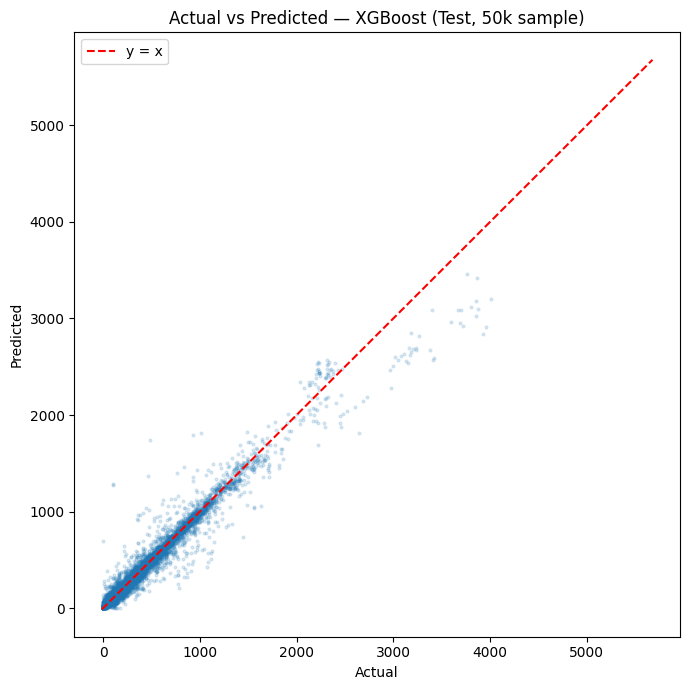

Saved: D:/dmp-project/result/output_energy_24h\report\actual_vs_predicted.png


In [15]:
# Chọn best model theo MAE thay vì RMSE (review #2)
best_name  = leaderboard.sort("Test_MAPE")["Model"][0]
best_model = trained[best_name]
y_pred     = best_model.predict(X_test)

# Sample 50k điểm để plot nhanh (17M điểm làm scatter rất chậm)
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), size=min(50_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test[idx], y_pred[idx], alpha=0.15, s=4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"Actual vs Predicted — {best_name} (Test, 50k sample)")
ax.legend()
plt.tight_layout()
plot_path = os.path.join(REPORT_DIR, "actual_vs_predicted.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Saved: {plot_path}')

## 8. Feature Importance

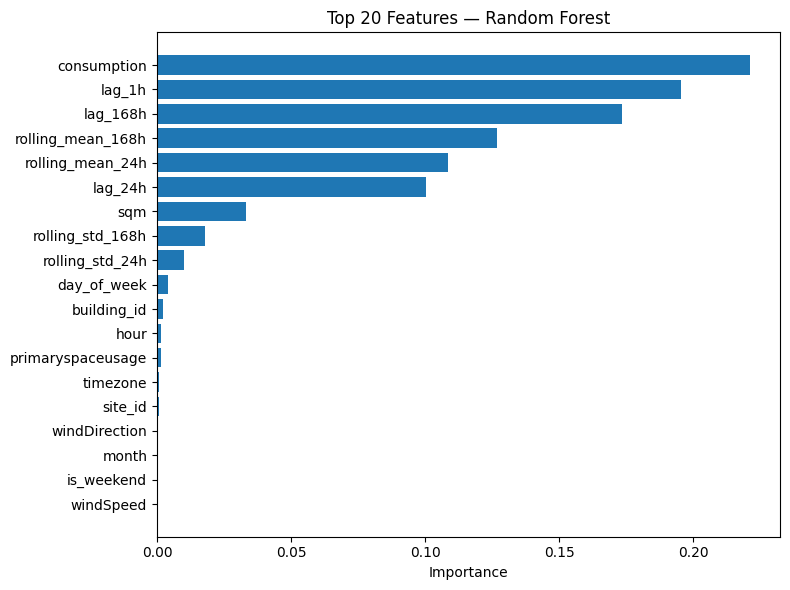

Saved: /content/output_energy_24h/report/feature_importance.png


In [ ]:
tree_model = best_model

if hasattr(tree_model, "feature_importances_"):
    importances = tree_model.feature_importances_
elif hasattr(tree_model, "get_booster"):
    score = tree_model.get_booster().get_score(importance_type="gain")
    importances = np.array([score.get(f"f{i}", 0) for i in range(len(FEATURE_COLS))])
else:
    importances = None

if importances is not None:
    top_k = 20
    idx   = np.argsort(importances)[-top_k:]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([FEATURE_COLS[i] for i in idx], importances[idx])
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_k} Features — {best_name}")
    plt.tight_layout()
    fi_path = os.path.join(REPORT_DIR, "feature_importance.png")
    plt.savefig(fi_path, dpi=120)
    plt.show()
    print(f'Saved: {fi_path}')
else:
    print(f'{best_name} does not expose feature importances.')

## 9. Save Artifacts

In [ ]:
for name, model in trained.items():
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(MODELS_DIR, f"{safe_name}.pkl")
    joblib.dump(model, path)
    print(f'Saved: {path}')

best_path = os.path.join(MODELS_DIR, "best_model.pkl")
joblib.dump(best_model, best_path)
print(f'\nBest model ({best_name}): {best_path}')

In [ ]:
!pip install tabulate

In [ ]:
lb_pd = leaderboard.to_pandas()

summary_lines = [
    "# Evaluation Summary",
    f"Dataset: {DATASET_SUBFOLDER}",
    "",
    "## Leaderboard",
    lb_pd.to_markdown(index=False),
    "",
    "## Best Model",
    best_name,
]

summary_path = os.path.join(REPORT_DIR, "evaluation_summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(summary_lines))
print(f'Saved: {summary_path}')

Saved: /content/output_energy_24h/report/evaluation_summary.md
